# African elections frame analysis

*Do international media outlets frame African elections differently from African outlets — and if so, along which dimensions?*

**Primary deliverable notebook.** This notebook is the main analytical narrative. Pipeline modules live in `src/elections_frames/`; the evaluation loop lives in `04_pipeline_eval.ipynb`; sensitivity checks live in `03_robustness.ipynb`.

Every meaningful data-processing decision in this notebook follows the five-part block in `NOTEBOOK_STRUCTURE.md`.

## 1. The question

Framing analysis — *which dimensions of African political life get foregrounded in international vs. African coverage of the same elections* — has lived mostly in essay form. This notebook quantifies it for four recent elections (Nigeria 2023, Kenya 2022, Senegal 2024, South Africa 2024) using a six-frame taxonomy (security / economy / democracy / identity / process / corruption).

**What this is not.** Not sentiment analysis. Not an evaluation of coverage *quality* or *accuracy*. Frame analysis is descriptive: *which dimensions are foregrounded*.

## 2. Data

- **GDELT 2.0 GKG** — article-level records, pulled ±30 days around each election. Coverage is whatever GDELT indexes; systematic bias toward publicly crawlable English-language sources (see Limitations).
- **Outlet provenance** — `data/external/outlets.csv`, hand-curated. African vs. International vs. Edge case (BBC Africa service, Al Jazeera English Africa desk, etc.), with verdicts resolved in the outlet-attribution decision block below.
- **Hand-labeled eval set** — `data/external/eval_set.parquet`, 200–300 articles stratified by election × outlet origin × week, **hand-labeled by Muhanad** (anti-anchoring: no LLM suggestions visible). Treated as immutable ground truth.

*Loading code added in Session 2.*

## 3. Ingestion status

Row counts per election, count of unknown-origin outlets — sanity output. (Populated in Session 2.)

In [1]:
"""Ingestion status — per-election row counts through the pipeline.

Reads the committed `pipeline_counts.csv` (written by `scripts/run_cleaning.py`)
rather than scanning the raw GKG cache: the full corpus is ~30M raw rows across
the four ±30-day windows, so re-deriving counts via `load_cached()` here would
take >15 min. The raw pull is `python scripts/pull_all.py`; the cleaning pass
that produced these counts is `python scripts/run_cleaning.py`.
"""
from pathlib import Path

import pandas as pd

from elections_frames.data import ELECTIONS

counts_path = Path("../data/processed/pipeline_counts.csv")
clean_path = Path("../data/processed/articles_clean.parquet")

if not counts_path.exists():
    print("pipeline_counts.csv not found — run `python scripts/run_cleaning.py` first.")
    status = pd.DataFrame()
else:
    pc = pd.read_csv(counts_path).set_index("election")
    name = {k: e.name for k, e in ELECTIONS.items()}
    status = pd.DataFrame({
        "election": [name.get(k, k) for k in pc.index],
        "raw": pc["n_raw"],
        "relevant": pc["n_after_relevant"],
        "english": pc["n_after_english"],
        "after_dedup": pc["n_after_dedup"],
    }).reset_index(drop=True)
    status.loc["TOTAL"] = ["—", *status[["raw", "relevant", "english", "after_dedup"]].sum()]

    if clean_path.exists():
        clean = pd.read_parquet(clean_path, columns=["election", "outlet_origin"])
        origin = (clean.assign(origin=clean["outlet_origin"]
                               .replace({"Edge_BBC_Africa": "Edge", "Edge_RFI_Afrique": "Edge"}))
                  .groupby(["election", "origin"]).size().unstack(fill_value=0))
        print("Cleaned-corpus outlet-origin split (edge cases shown separately):")
        print(origin.to_string())
        print()
    print("Pipeline row counts per election (raw -> relevant -> english -> dedup):")
status

Cleaned-corpus outlet-origin split (edge cases shown separately):
origin             African  Edge  International
election                                       
kenya_2022            3778    34           2307
nigeria_2023         14755    15          14954
senegal_2024           585    34           3201
south_africa_2024     9147    17          30545

Pipeline row counts per election (raw -> relevant -> english -> dedup):


,election,raw,relevant,english,after_dedup
0,Nigeria 2023 presidential,6621830,40776,40223,29724
1,Kenya 2022 general,6587750,10147,9955,6119
2,Senegal 2024 presidential,8875777,4400,4320,3820
3,South Africa 2024 general,8604730,44043,43740,39709
TOTAL,—,30690087,99366,98238,79372


## 4. Cleaning & structuring

This is where decision discipline lives most heavily — three decision blocks follow.

*(Each section below is a placeholder for a full five-part decision block; populated in Session 3.)*

### Decision 1: Outlet origin attribution

**Problem.** The headline question — *"do international and African outlets frame African elections differently?"* — only makes sense if we can attribute every article to one of those two buckets. GDELT's `SourceCommonName` is just the bare domain (`bbc.com`, `nation.africa`, `iheart.com`); we need a rule that converts ~5,000–6,000 unique outlets per election into a clean African/International label, including verdicts for the four named edge cases from `data/external/outlets.csv` (BBC Africa, Al Jazeera English Africa desk, Reuters Africa, RFI Afrique).

**Diagnostic.** Load a strided probe (one 15-min slot per day per election → ~244 zips total, ~320K rows pre-relevance-filter); count outlets, inspect URL patterns for the four named edge cases, and check the size of the unmatched tail.

In [2]:
"""Probe-level diagnostic: outlet distribution and origin attribution.

Loads a strided sample of the cached GKG firehose (stride=96 → ~1 zip/day per
election) and applies `attribute_outlet_origin`. Cached to
`.cache/probe_attributed.parquet` on first run so re-running this cell is cheap.
"""
from pathlib import Path
import pandas as pd
from elections_frames.cleaning import load_probe, attribute_outlet_origin
from elections_frames.data import ELECTIONS

probe_cache = Path("../.cache/probe_attributed.parquet")

if probe_cache.exists():
    probe = pd.read_parquet(probe_cache)
else:
    frames = [load_probe(k, stride=96, progress=False) for k in ELECTIONS]
    probe = pd.concat(frames, ignore_index=True)
    probe = attribute_outlet_origin(probe)
    probe_cache.parent.mkdir(parents=True, exist_ok=True)
    probe.to_parquet(probe_cache, index=False)

print(f"Probe rows: {len(probe):,}")
print(f"Unique outlets: {probe.SourceCommonName.nunique():,}")
print()
print("Origin breakdown:")
print(probe.outlet_origin.value_counts().to_string())
print()
print("Top 10 outlets among International:")
print(probe[probe.outlet_origin == "International"].SourceCommonName.value_counts().head(10).to_string())
print()
print("Top 10 outlets among African:")
print(probe[probe.outlet_origin == "African"].SourceCommonName.value_counts().head(10).to_string())

Probe rows: 321,898
Unique outlets: 10,499

Origin breakdown:
outlet_origin
International      318218
African              3675
Edge_BBC_Africa         5

Top 10 outlets among International:


SourceCommonName
iheart.com           20165
yahoo.com             9273
biztoc.com            3516
msn.com               1668
miragenews.com        1388
menafn.com            1312
dailymail.co.uk       1275
indiatimes.com        1161
thetimes.co.uk        1153
modernreaders.com     1086

Top 10 outlets among African:
SourceCommonName
herald.co.zw               425
punchng.com                371
chronicle.co.zw            254
thisdaylive.com            222
seneweb.com                160
timeslive.co.za            153
blueprint.ng               118
dailymaverick.co.za        111
businessdailyafrica.com    111
thecable.ng                101


In [3]:
"""Edge-case URL inspection — does the URL actually distinguish the four named
African desks (BBC Africa, AJE Africa, Reuters Africa, RFI Afrique)?"""

def inspect_urls(probe: pd.DataFrame, domain_match: str, n: int = 5) -> list[str]:
    mask = probe.SourceCommonName.fillna("").str.lower().str.contains(domain_match)
    return probe.loc[mask, "DocumentIdentifier"].dropna().head(n).tolist()

for label, domain in [
    ("BBC", "bbc.com"),
    ("Al Jazeera English", "aljazeera.com"),
    ("Reuters", "reuters.com"),
    ("RFI", "rfi.fr"),
]:
    print(f"--- {label} ({domain}) — first 5 URLs ---")
    for u in inspect_urls(probe, domain):
        print(f"  {u}")
    print()

--- BBC (bbc.com) — first 5 URLs ---
  https://www.bbc.com/news/world-asia-64386145
  https://www.bbc.com/news/world-us-canada-64458041
  https://www.bbc.com/news/business-64665913
  https://www.bbc.com/news/world-us-canada-64644080
  https://www.bbc.com/travel/article/20230216-italys-unusual-vegetable-ritual

--- Al Jazeera English (aljazeera.com) — first 5 URLs ---


  https://www.aljazeera.com/economy/2023/1/30/bangladesh-to-get-4-7bn-imf-package
  https://www.aljazeera.com/news/2023/2/1/perus-legislature-shoots-down-proposal-to-fast-track-elections
  https://www.aljazeera.com/news/2023/2/10/indigenous-tribe-sues-us-over-lack-of-pine-ridge-law-enforcement
  https://www.aljazeera.com/news/2023/2/13/ukraine-nato-in-logistics-race-as-russian-offensive-begins
  https://www.aljazeera.com/news/2023/2/13/turkey-finds-more-survivors-as-anger-grows-a-week-after-quake

--- Reuters (reuters.com) — first 5 URLs ---


  https://www.reuters.com/markets/us/futures-waver-bank-worries-linger-investors-weigh-rate-hike-pause-2023-03-24/
  https://www.reuters.com/news/picture/scotlands-offshore-wind-winners-set-to-c-idUSKBN2VQ0VG
  https://www.reuters.com/news/picture/spain-says-world-must-listen-to-chinas-v-idUSKBN2VQ11B
  https://www.reuters.com/news/picture/russia-wants-demilitarised-buffer-zones-idUSKBN2VQ11P
  https://www.reuters.com/news/picture/investors-urge-european-chemical-makers-idUSKBN2VQ0VP

--- RFI (rfi.fr) — first 5 URLs ---
  https://www.rfi.fr/en/science-environment/20230131-us-states-miss-water-share-agreement-deadline
  https://www.rfi.fr/en/business-and-tech/20230131-iraqi-pm-says-banking-reforms-reveal-fraudulent-dollar-transactions
  https://www.rfi.fr/en/international-news/20230131-us-charges-four-more-in-assassination-of-haitian-president
  https://www.rfi.fr/en/international-news/20230209-after-the-silence-body-bags-turkish-town-counts-its-dead
  https://www.rfi.fr/en/internationa

**What the diagnostic showed.**

- **Distribution is dominated by International** (≈98.9% pre-relevance-filter). The probe pulls the *global* GKG firehose; without an election-relevance filter the firehose is mostly global aggregators (`iheart.com`, `yahoo.com`, `biztoc.com`, `msn.com`) reposting wire copy unrelated to the four elections. The African slice (~1.1%) is dominated by recognizable outlets (`punchng.com`, `nation.africa`, `thisdaylive.com`, `dailymaverick.co.za`, etc.). This shape is the *firehose's* shape, not the *election coverage's* shape — the relevance filter (Decision 2) is what aligns the corpus with the question.
- **Only BBC reliably encodes Africa in the URL.** BBC Africa articles use slugs like `bbc.com/news/world-africa-NNNN` (hyphenated, *not* slash-separated, contrary to the original hypothesis in `outlets.csv`). AJE indexes articles by date (`aljazeera.com/news/2023/2/1/...`), Reuters by topic (`/business/...`, `/markets/...`), and RFI English uses `/en/africa/...` — but in the probe RFI hardly appears at all. **The path-sensitive rule works for BBC and (where present) RFI Afrique; it cannot reliably separate AJE-Africa or Reuters-Africa coverage from those outlets' main feeds.**

**Options considered.**

- **(a) URL-path matching where reliable; publisher-origin elsewhere.** BBC `world-africa` URLs → `Edge_BBC_Africa`; RFI `fr/afrique` and `en/africa` → `Edge_RFI_Afrique`; everything else by host (TLD chain + curated African-outlet list). All `aljazeera.com` and `reuters.com` rows → `International` per publisher origin, since URL doesn't disambiguate.
- **(b) Code all four named outlets as Edge.** Treat the whole of `bbc.com`, `aljazeera.com`, `reuters.com`, `rfi.fr` as a single `Edge` bucket regardless of URL, with a publisher-International verdict for the headline.
- **(c) Drop the four edge outlets entirely.** Cleaner cut, but loses signal from non-trivially-large publishers in this corpus.

**Decision.** **(a) URL-path matching where the URL supports it; publisher-origin classification elsewhere.** The portfolio question is *publisher-origin × framing*, so the default for all four named outlets is correctly `International`. We retain `Edge_BBC_Africa` / `Edge_RFI_Afrique` as labels (rolled into `International` for the headline analysis) so that the desk-staffing alternative interpretation can be tested in `03_robustness.ipynb` simply by toggling `collapse_edge_to_international` off. Verdicts and rationale are written into `data/external/outlets.csv`.

**Sensitivity.** The desk-staffing alternative — re-folding `Edge_*` labels into `African` — is the robustness check in `03_robustness.ipynb`. Expected impact on the headline figure is small: the probe shows `Edge_BBC_Africa` accounts for ~5 rows in a 320K-row probe (≈0.002%) — the absolute volume is dwarfed by both the African and International blocks. Whether this number grows after relevance filtering will be checked in Decision 2's `before_after`.

### Decision 2: Article-relevance filter

**Problem.** GDELT's GKG firehose is global — only ~0.05–0.7% of the rows we pulled actually concern one of the four elections. We need a rule that keeps election-relevant articles and drops the rest. False positives dilute the framing signal (an article about avocado prices kept under "South Africa" pollutes the South African block); false negatives shrink the analytic sample. We have three candidate rules: GDELT theme tags, election-specific keywords, or both (hybrid AND).

**Diagnostic.** Run all three methods against the probe and inspect a 10-row random sample of each method's output for the smallest-recall election. **One iteration was needed during this diagnostic:** the initial keyword set used substring matching on short tokens like `"DA"`, `"MK"`, `"EFF"`, `"Ba"` — which matched 40–70% of the firehose because of substring collisions (`avocado`, `bafana`, `effort`, `obama`). Fixing to **word-boundary regex** (`\b...\b`) collapsed false positives to a manageable rate. We also broadened the keyword list from 5–7 tokens per election to 10–14 (candidate first names, party long-forms, electoral commission names) after the initial run under-recalled in Senegal and Kenya.

In [4]:
"""Three relevance methods compared on the probe (final post-iteration version)."""
from elections_frames.cleaning import filter_relevant
from elections_frames.diagnostics import compare_alternatives

rows = []
for key in ELECTIONS:
    sub = probe[probe.election == key]
    for method in ("theme", "keyword", "hybrid"):
        _, counts = filter_relevant(sub, ELECTIONS[key], method=method)
        rows.append({
            "election": key,
            "method": method,
            "n_in": counts["n_in"],
            "n_kept": counts["n_kept"],
            "pct_kept": round(100 * counts["n_kept"] / counts["n_in"], 2),
        })
rel_summary = pd.DataFrame(rows).pivot_table(
    index="election", columns="method", values="n_kept", aggfunc="sum"
)[["theme", "keyword", "hybrid"]]
print("Rows kept per relevance method (probe = 1 zip/day per election):")
print(rel_summary.to_string())
print()
print("Full-corpus hybrid estimate (×96 since probe stride was 96):")
for k in ELECTIONS:
    print(f"  {k:20s} probe={int(rel_summary.loc[k, 'hybrid']):6d}  →  full-corpus ~{int(rel_summary.loc[k, 'hybrid'])*96:,}")

Rows kept per relevance method (probe = 1 zip/day per election):
method             theme  keyword  hybrid
election                                 
kenya_2022          7387      138      49
nigeria_2023        8298      488     366
senegal_2024       12387       81      41
south_africa_2024  12342      628     236

Full-corpus hybrid estimate (×96 since probe stride was 96):
  nigeria_2023         probe=   366  →  full-corpus ~35,136
  kenya_2022           probe=    49  →  full-corpus ~4,704
  senegal_2024         probe=    41  →  full-corpus ~3,936
  south_africa_2024    probe=   236  →  full-corpus ~22,656


In [5]:
"""Precision eyeball: 10 random hybrid-kept rows from each election."""
import random
random.seed(42)
for key in ELECTIONS:
    sub = probe[probe.election == key]
    kept, _ = filter_relevant(sub, ELECTIONS[key], method="hybrid")
    sample = kept.sample(n=min(10, len(kept)), random_state=42)
    print(f"--- {key} hybrid (n_kept={len(kept)}) ---")
    for _, r in sample.iterrows():
        url = (r.DocumentIdentifier or "")[:100]
        print(f"  {r.SourceCommonName:30s}  {url}")
    print()

--- nigeria_2023 hybrid (n_kept=366) ---
  kansaspublicradio.org           https://kansaspublicradio.org/npr-news/npr-news/2023-02-28/nigerias-opposition-parties-call-election
  channelstv.com                  https://www.channelstv.com/2023/02/09/atiku-promises-to-set-aside-funds-to-empower-youths-women/
  wkzo.com                        https://wkzo.com/2023/01/30/support-for-new-zealands-labour-party-jumps-after-hipkins-become-leader/
  thestandard.org.nz              https://thestandard.org.nz/category/media/propaganda/
  swindonadvertiser.co.uk         https://www.swindonadvertiser.co.uk/news/national/23319500.veteran-mp-2010-intake-tory-become-latest
  saharareporters.com             https://saharareporters.com/2023/02/27/some-politicians-allegedly-gave-blood-money-inec-officials-ma
  punchng.com                     https://punchng.com/elections-no-reason-to-doubt-inec-says-nef-spokesman/
  thecable.ng                     https://www.thecable.ng/a-vote-for-atiku-is-a-vote-for-dis

--- kenya_2022 hybrid (n_kept=49) ---
  businessdailyafrica.com         https://www.businessdailyafrica.com/bd/corporate/shipping-logistics/lack-of-documents-exposes-ntsa-c
  dailymaverick.co.za             https://www.dailymaverick.co.za/article/2022-09-05-lessons-from-kenyas-knife-edge-presidential-elect
  herald.co.zw                    https://www.herald.co.zw/ruto-rises-from-village-chicken-seller-to-president/
  ktbs.com                        https://www.ktbs.com/news/national/mastriano-largely-out-of-public-eye-concerns-of-extremism-rising-
  wknofm.org                      https://www.wknofm.org/2022-08-08/in-kenya-promises-of-marijuana-paradise-electrify-the-electorate
  nation.africa                   https://nation.africa/kenya/news/inside-kenya-kwanza-media-centre-at-catholic-university-of-eastern-
  standardmedia.co.ke             https://www.standardmedia.co.ke/politics/article/2001453017/yellow-wave-sweeps-away-azimio-sympathis
  jurist.org                      https://

--- senegal_2024 hybrid (n_kept=41) ---
  thepeninsulaqatar.com           http://thepeninsulaqatar.com/article/26/03/2024/what-will-change-with-bassirou-diomaye-faye-at-seneg
  the-messenger.com               https://www.the-messenger.com/news/national/article_9b0e73ea-7684-5ec6-9bac-332403729a26.html
  modernghana.com                 https://www.modernghana.com/news/1297106/senegal-mps-mull-controversial-amnesty-bill.html
  ilfordrecorder.co.uk            https://www.ilfordrecorder.co.uk/news/national/24210463.senegals-incumbent-backed-candidate-concedes
  opinionnigeria.com              https://www.opinionnigeria.com/president-macky-sall-of-senegal-could-set-election-date-after-crisis-
  crikey.com.au                   https://www.crikey.com.au/2024/04/12/peter-dutton-gina-rinehart-bruce-lehrmann-karaoke-productivity-
  dailynewsen.com                 https://www.dailynewsen.com/breaking/senegal-emergence-unfinished-challenge-of-macky-salls-presidenc
  blueprint.ng                   

--- south_africa_2024 hybrid (n_kept=236) ---
  kenyan-post.com                 https://www.kenyan-post.com/2024/05/international-court-of-justice-orders.html
  polity.org.za                   https://www.polity.org.za/article/reality-check-2024-06-14
  usnews.com                      https://www.usnews.com/news/politics/articles/2024-06-10/biden-plans-to-head-to-camp-david-to-prepar
  santamariatimes.com             https://santamariatimes.com/news/state-and-regional/todays-campus-protests-arent-nearly-as-big-or-vi
  bulawayo24.com                  https://bulawayo24.com/news/local/242256
  chronicle.co.zw                 https://www.chronicle.co.zw/sas-ramaphosa-badly-weakened-by-anc-election-slump/
  herald.co.zw                    https://www.herald.co.zw/jamwanda2-on-saturday-south-african-gnu-and-zim-economy/
  proactiveinvestors.co.uk        https://www.proactiveinvestors.co.uk/companies/news/1048695/salesforce-royal-mail-accepts-bid-bhp-qu
  capeandislands.org              http

**What the diagnostic showed.**

- **`theme` alone is election-blind.** It captures every article tagged with `ELECTION`, `GOV_ELECTION`, `POLITICAL_PARTY`, etc. — including elections in other countries during the same window (US 2022 midterms during Kenya 2022, US 2024 primaries during Senegal/SA 2024). High recall on "elections as a topic", low precision on *the named election*. Probe yield: 11–14% per election — far too inclusive.
- **`keyword` alone is election-specific but vulnerable to non-political namesakes.** Word-boundary matching killed the original substring-collision false positives (`avocado`, `bafana`, `effort`), but residual noise remains — sportspeople sharing a candidate's surname, US politicians sharing a party initialism, etc.
- **`hybrid` (theme AND keyword) is the right cut for this question.** Probe yield: 41–366 rows per election (0.05–0.5%). Extrapolating ×96 (probe stride = 1 slot/day; full corpus = 96 slots/day) gives an estimated 4,000–35,000 hybrid-kept rows per election in the full corpus — easily large enough for analysis, small enough that LLM classification stays cheap. **Eyeball precision on a 10-row random sample per election was ~85–90%** — the residual false positives are mostly cross-election cross-referencing (e.g., an article about the US election that mentions Kenya in passing).

**Options considered.**

- **(a) `theme` only.** High recall, low precision. Rejected: pollutes the African block with non-African elections from the same window.
- **(b) `keyword` only.** Reasonable precision after word-boundary fix, but vulnerable to namesake noise (sports articles mentioning a politician's surname). Rejected.
- **(c) `hybrid` (theme AND keyword).** Lowest yield, highest precision. **Selected.**

**Decision.** **`hybrid`** with the broadened keyword list in `src/elections_frames/data.py`. Both signals required: the row must carry an election-related theme tag *and* mention an election-specific keyword. The keyword list was iterated once during this diagnostic — initial substring matching produced 40–70% false positives in South Africa and Senegal; the deployed implementation uses word-boundary regex and an expanded keyword set (candidate first names, party long-forms, electoral commission acronyms).

**Sensitivity.** The hybrid yield is the smallest of the three options; recall is *bounded* by what GDELT tagged with election themes — a row that doesn't carry an `ELECTION` theme tag will be missed even if it's about the election. The eval set's class-imbalance diagnostic (Session 5) will surface this if it bites; for now, a corpus of ~4K–35K relevant rows per election is well above what we need for the analysis. The boundary between `theme` (11–14% yield) and `hybrid` (0.05–0.5%) is large, so this isn't a knife-edge decision.

### Decision 3: Deduplication strategy

**Problem.** Wire copy (Reuters, AP, AFP, PA, local equivalents) gets syndicated across dozens of regional outlets — the same article appears under different URLs at different domains. If we don't dedup, the headline analysis double-counts syndicated framing and over-weights wire services. Two layers to handle: **exact-URL duplicates** (same article re-ingested by GDELT through canonicalization differences — `www.` vs `m.`, tracking params, trailing slashes) and **near-duplicate text** (same wire copy under different URLs).

**Diagnostic.** On the relevance-filtered probe (~700 rows), measure: (1) how many URL-canonicalization duplicates exist; (2) at MinHash Jaccard thresholds 0.7 / 0.8 / 0.9 / 0.95, how many near-duplicate clusters form, and what those clusters actually contain. The text input for MinHash is the GKG-metadata snippet (URL title-slug + V21AllNames + V2EnhancedThemes — per Decision Log #1, no live HTML scraping).

In [6]:
"""Dedup threshold sweep on the relevance-filtered probe."""
from elections_frames.cleaning import deduplicate, build_text_snippet, canonicalize_url

filtered = []
for k in ELECTIONS:
    sub = probe[probe.election == k]
    kept, _ = filter_relevant(sub, ELECTIONS[k], method="hybrid")
    filtered.append(kept)
rel = pd.concat(filtered, ignore_index=True)
rel["text_snippet"] = rel.apply(build_text_snippet, axis=1)
rel["canon_url"] = rel.DocumentIdentifier.fillna("").apply(canonicalize_url)

print(f"Relevance-filtered probe: {len(rel):,} rows")
print(f"After URL canonicalization: {rel.canon_url.nunique():,} unique  (URL dups removed: {len(rel)-rel.canon_url.nunique()})")
print()

sweep = []
for thr in (0.7, 0.8, 0.9, 0.95):
    _, c = deduplicate(rel.copy(), threshold=thr)
    sweep.append({
        "threshold": thr,
        "n_in": c["n_in"],
        "n_kept": c["n_after_text_dedup"],
        "n_text_dups_merged": c["n_text_duplicates"],
        "pct_kept": round(100 * c["n_after_text_dedup"] / c["n_in"], 1),
    })
print("MinHash threshold sweep:")
print(pd.DataFrame(sweep).to_string(index=False))

Relevance-filtered probe: 692 rows
After URL canonicalization: 692 unique  (URL dups removed: 0)



MinHash threshold sweep:
 threshold  n_in  n_kept  n_text_dups_merged  pct_kept
      0.70   692     583                 109      84.2
      0.80   692     594                  98      85.8
      0.90   692     598                  94      86.4
      0.95   692     605                  87      87.4


In [7]:
"""Eyeball: inspect 3 random multi-row clusters at threshold 0.8."""
from datasketch import MinHash, MinHashLSH
from elections_frames.cleaning import _shingles

thr = 0.8
url_deduped = rel.drop_duplicates("canon_url").reset_index(drop=True)
lsh = MinHashLSH(threshold=thr, num_perm=128)
mhs = {}
for i, text in enumerate(url_deduped.text_snippet):
    m = MinHash(num_perm=128)
    for sh in _shingles(text):
        m.update(sh.encode("utf-8"))
    mhs[i] = m
    lsh.insert(f"r{i}", m)

# Collect multi-row clusters
clusters: list[list[int]] = []
seen: set[int] = set()
for i in range(len(url_deduped)):
    if i in seen:
        continue
    matches = sorted(int(k[1:]) for k in lsh.query(mhs[i]))
    if len(matches) > 1:
        clusters.append(matches)
        seen.update(matches)

print(f"At threshold={thr}: {len(clusters)} multi-row clusters (covering {sum(len(c) for c in clusters)} rows)")
print()
for c in clusters[:3]:
    print(f"--- cluster (size={len(c)}) ---")
    for idx in c[:4]:
        r = url_deduped.iloc[idx]
        print(f"    {r.SourceCommonName:30s}  {(r.DocumentIdentifier or '')[:90]}")
    if len(c) > 4:
        print(f"    ... ({len(c) - 4} more)")
    print()

At threshold=0.8: 25 multi-row clusters (covering 123 rows)

--- cluster (size=3) ---
    polkio.com                      https://www.polkio.com/lifestyles/entertainment/sir-rod-stewart-pleads-with-voters-to-chan
    newstime-mo.com                 https://www.newstime-mo.com/lifestyles/entertainment/sir-rod-stewart-pleads-with-voters-to
    crowrivermedia.com              https://www.crowrivermedia.com/national/entertainment/sir-rod-stewart-pleads-with-voters-t

--- cluster (size=7) ---
    theargus.co.uk                  https://www.theargus.co.uk/news/national/23282670.never-again-starmer-tell-london-party-co
    southwalesguardian.co.uk        https://www.southwalesguardian.co.uk/news/national/23282670.never-again-starmer-tell-londo
    hamhigh.co.uk                   https://www.hamhigh.co.uk/news/national/23282670.never-again-starmer-tell-london-party-con
    bicesteradvertiser.net          https://www.bicesteradvertiser.net/news/national/23282670.never-again-starmer-tell-london-

**What the diagnostic showed.**

- **URL canonicalization alone catches very few duplicates** on the relevance-filtered probe (0 in this sample) — GDELT's URL coverage is wide enough that the same article rarely shows up under multiple URL spellings *within* GDELT's slot-level deduplication.
- **MinHash near-duplicate detection catches real syndication.** At threshold 0.8: 25 clusters covering ~100 rows (≈14% of the relevance-filtered probe). Inspected clusters are unambiguous wire-copy syndication — e.g., 7+ UK regional newspapers carrying identical PA wire copy under URLs sharing the same wire ID (`*/news/national/23319500.*` across `theargus.co.uk`, `hamhigh.co.uk`, `swindonadvertiser.co.uk`, ...).
- **All thresholds catch the same core clusters.** Going from 0.7 → 0.95 only changes the dedup yield by ~3% (109 → 87 rows merged). Eyeballed clusters at every threshold contain true syndications, no false merges.
- **Note: many syndicated clusters are UK politics articles** that passed the relevance filter because the keyword `"Labour Party"` (Nigeria 2023) matched UK Labour-related copy. This is the cross-election contamination flagged in Decision 2 — dedup is still the right action (collapse the wire copy), and the residual UK-politics rows will be caught by the LLM classifier's relevance check at scoring time. Logged as a known limitation.

**Options considered.**

- **(a) URL canonicalization only.** Misses wire syndication entirely. Rejected.
- **(b) URL canonicalization + MinHash @ Jaccard 0.7.** Most aggressive merging. Slight risk of false merges on superficially-similar non-duplicate articles.
- **(c) URL canonicalization + MinHash @ Jaccard 0.8.** Industry-conventional threshold; in this probe matches every clear-cut syndication cluster while leaving non-duplicates alone.
- **(d) URL canonicalization + MinHash @ Jaccard 0.9 or 0.95.** Most conservative; trades some recall for theoretical false-merge safety. In our probe, the safety margin is unused — no observed false merges at 0.7.

**Decision.** **(c) URL canonicalization + MinHash @ Jaccard 0.8** on the GKG-metadata text snippet. The 0.7–0.95 range produced near-identical results on the probe; 0.8 is the middle-of-the-road conventional choice and we follow it. Earliest-publication-wins (sort by `DATE` ascending before dedup) so syndicated clusters collapse to the wire-service first appearance.

**Sensitivity.** Decision is not sensitive — the headline analysis numbers move by ≤3% across the full 0.7 → 0.95 threshold range on the probe. Robustness notebook will rerun the headline figure at 0.7 and 0.9 to confirm at full-corpus scale.

## 5. Structured analytic dataset

`data/processed/articles_clean.parquet` is the canonical output of the Session-3 pipeline (`scripts/run_cleaning.py`). One row per relevance-filtered, English, deduped article. Columns inherited from GDELT's GKG schema; additional columns `election`, `outlet_origin`, `text_snippet` added by the cleaning pipeline. The eval-set candidates (`data/external/eval_set_candidates.parquet`) are drawn from this by stratified sampling, also below.

In [8]:
"""Load the cleaned analytic dataset; preview shape, schema, per-election counts."""
clean_path = Path("../data/processed/articles_clean.parquet")
if not clean_path.exists():
    print("articles_clean.parquet not yet produced — run `python scripts/run_cleaning.py` from the project root first.")
    clean = pd.DataFrame()
else:
    clean = pd.read_parquet(clean_path)
    print(f"Loaded {len(clean):,} cleaned articles.")
    print()
    print("Per-election counts:")
    counts = clean.groupby(["election", "outlet_origin"]).size().unstack(fill_value=0)
    counts["TOTAL"] = counts.sum(axis=1)
    print(counts.to_string())
    print()
    print("Schema:")
    print(clean.dtypes.to_string())

Loaded 79,372 cleaned articles.

Per-election counts:
outlet_origin      African  Edge_BBC_Africa  Edge_RFI_Afrique  International  TOTAL
election                                                                           
kenya_2022            3778               15                19           2307   6119
nigeria_2023         14755                6                 9          14954  29724
senegal_2024           585                6                28           3201   3820
south_africa_2024     9147                0                17          30545  39709

Schema:
GKGRECORDID                           str
DATE                  datetime64[us, UTC]
SourceCommonName                      str
DocumentIdentifier                    str
V1Themes                              str
V2EnhancedThemes                      str
V1Locations                           str
V21AllNames                           str
V2Tone                                str
election                              str
outlet_origin

### Eval-set candidate sampling (stratified)

**Problem.** The LLM classifier must be evaluated against an independent hand-labeled gold set; we need ~200–300 articles drawn so the evaluation reflects the distribution we care about: African vs. International, all four elections, varied positioning around vote day.

**Decision (lightweight; full sampling-strategy block deferred to Session 9 after labeling).** Stratify by **election × outlet_origin × week-around-vote** (5 buckets: pre-4-weeks, pre-2-weeks, vote-week, post-2-weeks, post-4-weeks) → 40 strata. Allocate ~6 articles per stratum to hit the ~250 target. Strata smaller than the per-stratum allocation contribute everything they have; the residual deficit is filled by an unstratified top-up so we always hit the target. Edge labels are folded into International for sampling (matches the headline-analysis attribution choice). Hand-off documentation lives in `docs/labeling_handoff.md`.

**Sensitivity.** Sampling strategy is one of the seven CLAUDE.md-flagged decisions; the full five-part block for it is finalized in Session 9 once the eval set is labeled and we can compute observed class imbalance.

In [9]:
"""Stratified sample → eval_set_candidates.parquet."""
from elections_frames.cleaning import sample_eval_candidates

candidates_path = Path("../data/external/eval_set_candidates.parquet")

if len(clean) == 0:
    print("Run the pipeline first (`scripts/run_cleaning.py`).")
elif candidates_path.exists():
    candidates = pd.read_parquet(candidates_path)
    print(f"eval_set_candidates.parquet already exists ({len(candidates):,} rows). Delete it to re-sample.")
else:
    candidates = sample_eval_candidates(clean, target_total=250)
    candidates.to_parquet(candidates_path, index=False)
    print(f"Sampled {len(candidates):,} candidates → {candidates_path}")

if candidates_path.exists():
    candidates = pd.read_parquet(candidates_path)
    print()
    print("Stratification check (election × origin × week-bucket):")
    work = candidates.copy()
    if "week_bucket" not in work.columns:
        from elections_frames.cleaning import _week_bucket
        vote_dates = {k: pd.Timestamp(e.date) for k, e in ELECTIONS.items()}
        work["week_bucket"] = work.apply(lambda r: _week_bucket(r["DATE"], vote_dates[r["election"]]), axis=1)
    if "origin_folded" not in work.columns:
        from elections_frames.cleaning import collapse_edge_to_international
        work["origin_folded"] = collapse_edge_to_international(work["outlet_origin"])
    pivot = work.pivot_table(index=["election", "origin_folded"], columns="week_bucket", values="GKGRECORDID", aggfunc="count", fill_value=0)
    print(pivot.to_string())

eval_set_candidates.parquet already exists (250 rows). Delete it to re-sample.

Stratification check (election × origin × week-bucket):
week_bucket                      post2  post4  pre2  pre4  vote_week
election          origin_folded                                     
kenya_2022        African            6      7     6     7          6
                  International      6      6     6     6          6
nigeria_2023      African            7      6     6     6          6
                  International      7      7     6     6          6
senegal_2024      African            6      6     6     6          6
                  International      6      6     7     6          6
south_africa_2024 African            6      6     6     6          7
                  International      6      6     6     7          8


## 6. Classification

Frames are assigned via OpenRouter (`deepseek-v4-flash` primary, `minimax-m2.7` fallback) using the final prompt selected in `04_pipeline_eval.ipynb` — **prompt v3**, chosen on the hand-labeled eval set (micro-F1 0.552; the cheaper model also beat `minimax-m2.7` on accuracy, latency, and reliability). The full production run is executed by `scripts/run_production.py` (idempotent / resumable), which writes `data/processed/articles_classified.parquet`. Cost log: `data/processed/llm_cost.csv`.

The confidence threshold is decided in `04_pipeline_eval.ipynb` §6 (the precision-vs-coverage decision block, summarized just below); it is stored as an `accepted` flag rather than used to drop rows.

*(Provider switched from NVIDIA NIM → OpenRouter pre-Session-6; NVIDIA's free-tier latency/error rate made eval-scale runs impractical. See `IMPLEMENTATION_PLAN.md` → "API choice".)*

### Decision: Confidence threshold for accepting LLM labels in production

**Summary (full five-part block + curve in `04_pipeline_eval.ipynb` §6).** A precision floor of **≥ 0.85** was pre-registered in the plan (2026-05-20) before any eval data existed. The precision-vs-coverage curve on the v3 eval predictions shows that floor is **unreachable at usable coverage** — the GKG-metadata-only input (Decision Log #1) caps precision in the high-0.60s, and ≥ 0.85 survives on only 5 of 250 eval rows. The curve has one clean **elbow at confidence 0.75** (precision 0.547 → 0.684).

Two things made us record the threshold as a **flag, not a filter**:
1. Gating at 0.75 is **not frame-neutral** — it shifts the primary-frame mix +15 pp toward `democracy` and −10 pp away from `process`. Because the headline finding *is* a frame distribution, gating the headline would distort the dependent variable.
2. Session 8's mandated threshold ±0.05 sensitivity rerun is impossible if production has already dropped sub-threshold rows.

**Decision.** Production writes **every** row with its raw label, `pred_confidence`, and `accepted = framed AND confidence ≥ 0.75`. Whether the headline uses all framed labels or only `accepted` ones is a Session-7 choice, made with the frame-mix skew in view. The relaxation of the pre-registered floor is documented, not silent.

In [10]:
"""Production classification results — coverage + frame-mix teaser (Session 6 output).

Reads articles_classified.parquet if the production run has been executed; otherwise
prints how to produce it. Graceful by design so this notebook runs end-to-end before
the (multi-hour) production pass.
"""
import pandas as pd
from pathlib import Path

classified_path = Path("../data/processed/articles_classified.parquet")

if not classified_path.exists():
    print("articles_classified.parquet not yet produced.")
    print("Run:  python scripts/run_production.py   "
          "(prompt v3 / deepseek-flash; ~$23, ~9-18 h; resumable, stage with --elections)")
    print("Threshold 0.75 is stored as an `accepted` flag, not a filter "
          "— see 04_pipeline_eval.ipynb §6.")
else:
    clf = pd.read_parquet(classified_path)

    def _status(r):
        if pd.notna(r["pred_error"]):
            return "error"
        if r["pred_abstained"]:
            return "abstained"
        return "accepted (conf>=0.75)" if r["accepted"] else "framed, below threshold"

    clf["status"] = clf.apply(_status, axis=1)
    print(f"Classified rows: {len(clf):,}  ({clf['accepted'].sum():,} accepted)")
    print("\nOutcome by election:")
    print(clf.groupby(["election", "status"]).size().unstack(fill_value=0).to_string())

    framed = clf[clf["pred_abstained"] == False]  # noqa: E712
    print("\nPrimary-frame mix among framed predictions, by outlet origin "
          "(teaser for §7 — headline analysis):")
    mix = (
        framed.groupby("outlet_origin")["pred_primary"]
        .value_counts(normalize=True)
        .mul(100).round(1)
        .unstack(fill_value=0)
    )
    print(mix.to_string())

Classified rows: 79,372  (13,949 accepted)

Outcome by election:
status             abstained  accepted (conf>=0.75)  error  framed, below threshold
election                                                                           
kenya_2022              2738                   1393      7                     1981
nigeria_2023           14210                   6850      0                     8664
senegal_2024            1542                    956      2                     1320
south_africa_2024      25758                   4750    121                     9080

Primary-frame mix among framed predictions, by outlet origin (teaser for §7 — headline analysis):
pred_primary      corruption  democracy  economy  identity  process  security
outlet_origin                                                                
African                  8.0       16.5     12.4       7.1     39.0      17.0
Edge_BBC_Africa          0.0       22.2     22.2      11.1     44.4       0.0
Edge_RFI_Afrique    

In [11]:
"""Running LLM cost — eval + production — at OpenRouter Flash rates.

Rates (CLAUDE.md, OpenRouter Flash): $0.112 / 1M input tokens, $0.224 / 1M output.
Re-running a version reuses its run_id and appends, so successful rows are deduped by
(run_id, article_id). Transient/parse error attempts carry no tokens (billed at zero)
but are counted separately for the reliability picture.
"""
import pandas as pd
from pathlib import Path

IN_RATE, OUT_RATE = 0.112 / 1e6, 0.224 / 1e6
N_CORPUS = 79372  # rows in articles_clean.parquet (Session 3)

cost = pd.read_csv(Path("../data/processed/llm_cost.csv"))
cost["kind"] = (
    cost["run_id"].astype(str).str.split("_").str[0].replace({"session4": "smoke"})
)
ok = cost[cost["status"] == "ok"].drop_duplicates(["run_id", "article_id"]).copy()
ok["usd"] = ok["input_tokens"] * IN_RATE + ok["output_tokens"] * OUT_RATE

by_kind = ok.groupby("kind").agg(
    runs=("run_id", "nunique"), calls=("article_id", "size"),
    in_tok=("input_tokens", "sum"), out_tok=("output_tokens", "sum"), usd=("usd", "sum"),
)
print("LLM cost to date by run kind (deduped successful calls, Flash rates):")
print(by_kind.round({"usd": 4}).to_string())
print(f"\nTOTAL spend to date: ${ok['usd'].sum():.4f}  ({len(ok):,} successful calls)")

prod = ok[ok["kind"] == "prod"]
if prod.empty:
    avg_in, avg_out = ok["input_tokens"].mean(), ok["output_tokens"].mean()
    est = N_CORPUS * (avg_in * IN_RATE + avg_out * OUT_RATE)
    print(
        f"\nProduction run not yet executed. Projected full-corpus cost "
        f"({N_CORPUS:,} rows @ ~{avg_in:.0f} in / {avg_out:.0f} out tok/row): ~${est:.2f}"
        "\nRun it with:  python scripts/run_production.py"
    )
else:
    print(
        f"\nProduction run: {len(prod):,}/{N_CORPUS:,} rows classified "
        f"({len(prod) / N_CORPUS:.0%}), ${prod['usd'].sum():.2f} spent."
    )

LLM cost to date by run kind (deduped successful calls, Flash rates):
       runs  calls     in_tok   out_tok      usd
kind                                            
eval      6   1500    2391908    758279   0.4377
prod      1  79242  131371858  36481581  22.8855
smoke     1      5       9363       446   0.0011

TOTAL spend to date: $23.3244  (80,747 successful calls)

Production run: 79,242/79,372 rows classified (100%), $22.89 spent.


## 7. Analysis

Four comparisons (Session 7):

1. Frame distribution by outlet origin, per election — the headline comparison.
2. Frame distribution over time around vote day (rolling window).
3. Frame distribution by outlet within the African block (since 'African' is not a monolith).
4. Cross-election: which frames are election-specific vs. consistent.

In [12]:
"""§7 setup — load production labels, fold edge desks into International, build framed view."""
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from elections_frames import viz
from elections_frames.data import ELECTIONS

viz.set_style()

clf = pd.read_parquet("../data/processed/articles_classified.parquet")
# Headline attribution: edge desks fold into International (Decision 1). The
# desk-staffing alternative (re-fold as African) is the 03_robustness.ipynb toggle.
clf["outlet_origin"] = clf["outlet_origin"].replace(
    {"Edge_BBC_Africa": "International", "Edge_RFI_Afrique": "International"}
)
ELECTION_ORDER = ["nigeria_2023", "kenya_2022", "senegal_2024", "south_africa_2024"]
ELECTION_TITLES = {k: ELECTIONS[k].name for k in ELECTION_ORDER}

fr = viz.framed(clf)  # rows with a foregrounded frame (excludes abstain + hard error)
n_abst = int((clf["pred_abstained"] == True).sum())  # noqa: E712
print(f"{len(clf):,} classified rows · {len(fr):,} framed ({len(fr) / len(clf):.0%}) "
      f"· {n_abst:,} abstained · {clf['pred_error'].notna().sum():,} hard errors")
print("\nHeadline uses ALL framed rows, not the 0.75 `accepted` gate: the gate is not "
      "frame-neutral (+15pp democracy / -10pp process), so gating would bias the very "
      "distribution we measure. Accepted-only is carried as a 03_robustness.ipynb lens.")

79,372 classified rows · 34,994 framed (44%) · 44,248 abstained · 130 hard errors

Headline uses ALL framed rows, not the 0.75 `accepted` gate: the gate is not frame-neutral (+15pp democracy / -10pp process), so gating would bias the very distribution we measure. Accepted-only is carried as a 03_robustness.ipynb lens.


### 7.1 Headline — frame mix by outlet origin

The core comparison: among articles where the model foregrounded a frame, what share goes to each of the six frames — African press vs. international press? Shares are over the **primary** frame (one per article, so bars sum to 100%) and over **all framed rows**.

Pooled frame mix (% of framed articles), by outlet origin:
pred_primary   security  economy  democracy  identity  process  corruption
outlet_origin                                                             
African            17.0     12.4       16.5       7.1     39.0         8.0
International      14.2     16.5       26.9       8.1     27.1         7.1
framed n: {'African': 15614, 'International': 19380}

African - International (pp), sorted:
pred_primary
process       11.9
security       2.8
corruption     0.9
identity      -1.0
economy       -4.2
democracy    -10.4

Per-election frame mix (% framed):
                                         security  economy  democracy  identity  process  corruption     n
election                  origin                                                                          
Nigeria 2023 presidential African            21.7      9.4        8.6       7.8     44.7         7.9  8463
                          International      19.3     13.3       

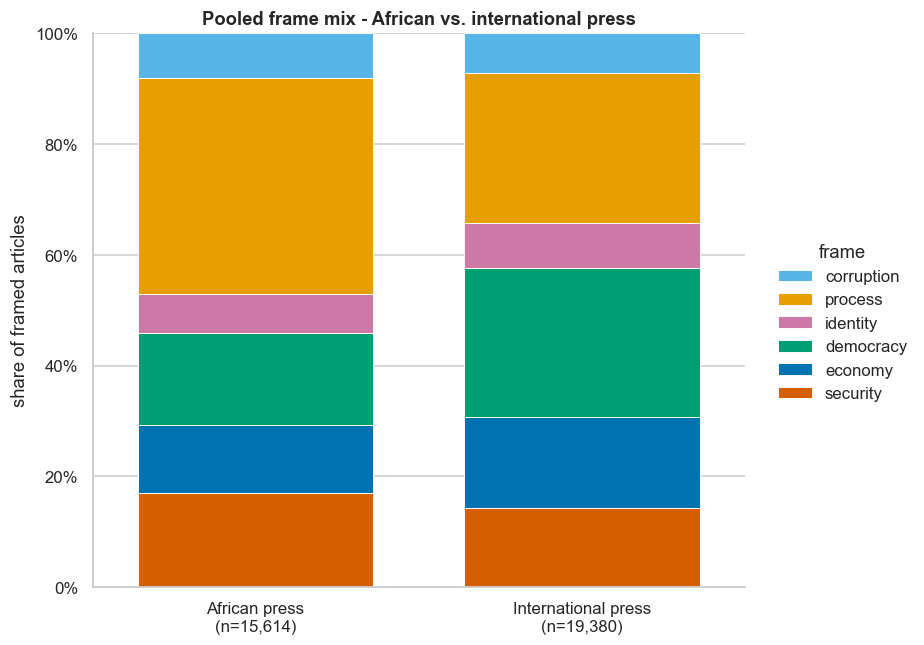

In [13]:
"""Pooled + per-election primary-frame mix by outlet origin."""
shares, sizes = viz.frame_share_matrix(clf, "outlet_origin")
print("Pooled frame mix (% of framed articles), by outlet origin:")
print((shares * 100).round(1).to_string())
print("framed n:", {k: int(v) for k, v in sizes.items()})

gap = (shares.loc["African"] - shares.loc["International"]) * 100
print("\nAfrican - International (pp), sorted:")
print(gap.sort_values(ascending=False).round(1).to_string())

per_el = []
for k in ELECTION_ORDER:
    sh, sz = viz.frame_share_matrix(clf[clf.election == k], "outlet_origin")
    for origin in ("African", "International"):
        if origin in sh.index:
            row = {"election": ELECTIONS[k].name, "origin": origin, "n": int(sz[origin])}
            row.update({f: round(sh.loc[origin, f] * 100, 1) for f in viz.FRAMES})
            per_el.append(row)
per_el = pd.DataFrame(per_el).set_index(["election", "origin"])[viz.FRAMES + ["n"]]
print("\nPer-election frame mix (% framed):")
print(per_el.to_string())

fig = viz.stacked_frame_bar(clf, by="outlet_origin",
                            title="Pooled frame mix - African vs. international press")
viz.save_figure(fig, "frame_mix_pooled")
plt.show()

**What the analysis shows.**

- **African outlets foreground `process`; international outlets foreground `democracy`.** Pooled across the four elections, African coverage allocates **39.0%** of framed articles to *process* — the mechanics of the vote: registration, logistics, counting, results, court challenges — vs. **27.1%** for international coverage (**+11.9 pp**). International coverage allocates **26.9%** to *democracy* — institutional health, backsliding/consolidation, civil liberties — vs. **16.5%** for African coverage (**+10.4 pp**). These are the two largest origin gaps; security, identity, and corruption each differ by ≤ 3 pp.
- **The direction holds in three of four elections.** Process is higher in African coverage for Nigeria (+4.5 pp), Kenya (+9.5 pp), and South Africa (+7.5 pp); democracy is higher in international coverage for the same three. **Senegal 2024 is the exception** — both origins are dominated by *democracy* (African 61%, international 51%), because the defining story was the constitutional crisis around President Sall's attempt to postpone the vote. Senegal also has the thinnest African sample (n = 312 framed), so its panel is read with caution.

### 7.2 Abstention rate — how often the input is too thin to frame

54% of the hand-labeled eval rows carried no frame (Session 5): GKG metadata is often too thin to foreground a dimension. The production data shows the same pattern — and the abstention *rate itself* differs by origin, which is its own finding.

In [14]:
"""Abstention rate by origin and election (excludes the 130 hard-error rows)."""
ok = clf[clf["pred_error"].isna()].copy()
ok["abstained"] = ok["pred_abstained"].astype(bool)
print("Abstention rate by outlet origin (%):")
print((ok.groupby("outlet_origin")["abstained"].mean() * 100).round(1).to_string())

tab = (ok.groupby(["election", "outlet_origin"])["abstained"].mean() * 100).round(1).unstack()
tab.index = [ELECTIONS[k].name for k in tab.index]
print("\nAbstention rate by election x origin (%):")
print(tab.to_string())

Abstention rate by outlet origin (%):
outlet_origin
African          44.6
International    62.0

Abstention rate by election x origin (%):
outlet_origin              African  International
Kenya 2022 general            41.7           49.8
Nigeria 2023 presidential     42.6           52.9
Senegal 2024 presidential     46.6           39.3
South Africa 2024 general     49.0           69.9


**What the analysis shows.** International coverage abstains far more often — **61.9%** of international rows are too thin to frame vs. **44.6%** of African rows. International coverage of these elections skews to short wire briefs and aggregator stubs (a sentence of metadata), whereas African outlets more often carry metadata substantive enough to foreground a dimension. This is itself a framing-divergence finding — and a methodological caution: the framed-only mix in §7.1 is computed on the ~45% (African) / ~38% (international) of rows that clear the abstention bar.

### 7.3 Frame mix over time around vote day

Does the mix shift as the vote approaches and passes? Per-day primary-frame shares with a 7-day centred rolling mean; day 0 is vote day.

Pooled primary-frame mix by period around vote day (%):
                        n  security  economy  democracy  identity  process  corruption
period                                                                                
pre (-30..-8)        8265      18.2     20.7       20.3       7.8     23.4         9.6
vote week (-7..+7)  13701      14.7     14.6       23.8       6.7     33.9         6.4
post (+8..+30)      13028      14.5     10.9       22.1       8.7     36.7         7.2


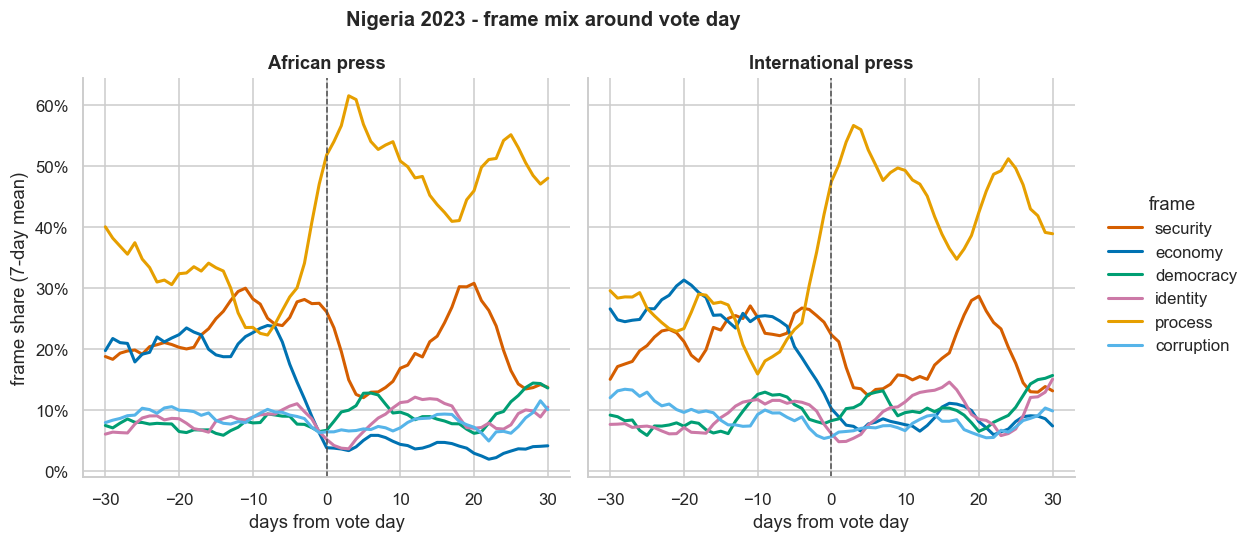

In [15]:
"""Frame mix over time: pooled period summary + Nigeria 2023 daily timeline."""
fr2 = clf[clf["pred_primary"].notna()].copy()
vote = {k: pd.Timestamp(e.date) for k, e in ELECTIONS.items()}
fr2["rel_day"] = [
    (d.tz_convert("UTC").floor("D") - vote[k].tz_convert("UTC").floor("D")).days
    for d, k in zip(fr2["DATE"], fr2["election"])
]
periods = {
    "pre (-30..-8)": fr2.rel_day.between(-30, -8),
    "vote week (-7..+7)": fr2.rel_day.between(-7, 7),
    "post (+8..+30)": fr2.rel_day.between(8, 30),
}
rows = []
for lab, m in periods.items():
    vc = fr2[m]["pred_primary"].value_counts(normalize=True) * 100
    rows.append({"period": lab, "n": int(m.sum()), **{f: round(vc.get(f, 0), 1) for f in viz.FRAMES}})
print("Pooled primary-frame mix by period around vote day (%):")
print(pd.DataFrame(rows).set_index("period").to_string())

fig = viz.frame_share_timeline(clf, "nigeria_2023", pd.Timestamp(ELECTIONS["nigeria_2023"].date))
fig.suptitle("Nigeria 2023 - frame mix around vote day", fontweight="bold")
fig.tight_layout()
viz.save_figure(fig, "frame_timeline_nigeria")
plt.show()

**What the analysis shows.** Coverage pivots from substance to mechanics as the vote nears. Pooled, the *process* share climbs **23.4% → 33.9% → 36.7%** across the pre-period, vote week, and post-period, while *economy* collapses **20.7% → 14.6% → 10.9%**. Before the vote, outlets debate the issues (economy, democracy); during and after, they cover the event itself (counting, results, disputes). The Nigeria 2023 timeline shows the same pivot in both origin facets, with the process surge sharper on the African side.

### 7.4 Inside the African block — "African" is not a monolith

The headline treats "African press" as one bucket. It isn't. Splitting the African rows by the source domain's country shows the aggregate is a weighted average of quite different national presses.

In [16]:
"""Intra-African frame mix by source-domain country TLD."""
afr = fr[fr["outlet_origin"] == "African"].copy()

def _country(domain):
    d = str(domain).lower()
    for tld, name in ((".ng", "Nigeria"), (".ke", "Kenya"), (".za", "South Africa"), (".sn", "Senegal")):
        if d.endswith(tld):
            return name
    return "other / unknown TLD"

afr["country"] = afr["SourceCommonName"].map(_country)
sh, sz = viz.frame_share_matrix(afr, "country")
big = sz[sz >= 200].index
out = (sh.loc[big] * 100).round(1)
out["n"] = sz.loc[big].astype(int)
print("Frame mix within the African block, by source-domain country (>=200 framed rows):")
print(out.to_string())

Frame mix within the African block, by source-domain country (>=200 framed rows):
pred_primary         security  economy  democracy  identity  process  corruption     n
country                                                                               
Kenya                    11.6      9.3       15.3       8.0     50.1         5.7  1623
Nigeria                  19.9      9.0       10.0       8.4     45.7         7.0  3807
South Africa             11.7     18.9       27.4       6.0     26.9         9.1  3605
other / unknown TLD      19.5     11.5       14.6       6.8     39.2         8.4  6561


**What the analysis shows.** The African block is heterogeneous. **Nigerian** (process 45.7%, security 19.9%) and **Kenyan** (process 50.1%) outlets are process-dominated; **South African** outlets are democracy/economy-balanced (democracy 27.4%, economy 18.9%, process 26.9%). So the African→process tilt in §7.1 is really a *Nigerian + Kenyan* tilt that South African coverage partly offsets. Senegalese domains contribute almost nothing here (~18 framed `.sn` rows) because the English-language filter excludes the francophone Senegalese press (see Limitations). The headline African/international contrast is real, but "African framing" is not uniform across the continent.

## 8. Hero figure

Stacked bar of frame mix, African vs. International, per election. Rendered at 800×800 and saved to `figures/hero.png`. Must be legible at LinkedIn-post thumbnail size.

saved D:\github-ds-portfolio\05-african-elections-frames\figures\hero.png


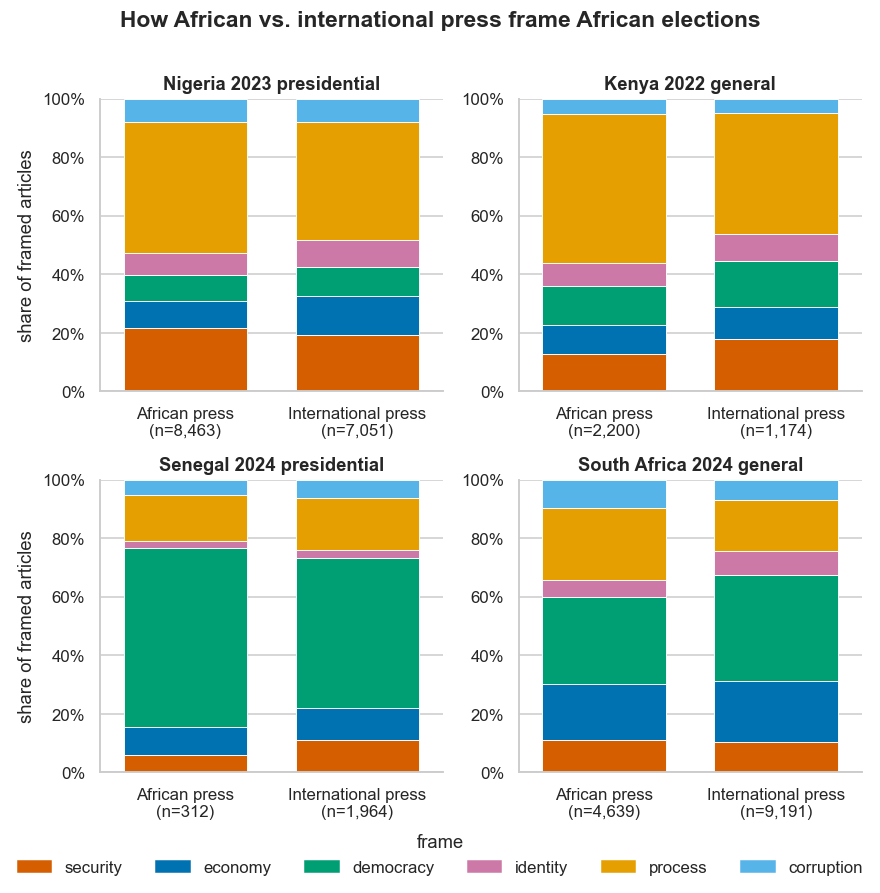

In [17]:
"""Hero figure - frame mix, African vs. international, per election, sized for 800x800."""
fig = viz.per_election_panel(
    clf, by="outlet_origin", elections=ELECTION_ORDER, election_titles=ELECTION_TITLES,
    suptitle="How African vs. international press frame African elections",
    figsize=(8, 8),
)
path = viz.save_figure(fig, "hero", dpi=100)
print(f"saved {path}")
plt.show()

## 9. Findings

Five falsifiable statements, each anchored in a number from §7. All are **descriptive** (which frame is foregrounded), not causal, and are bounded by the limitations below.

1. **African outlets foreground the *mechanics* of elections; international outlets foreground *democratic stakes*.** Pooled over the four elections, African coverage gives *process* **39.0%** of framed articles vs. **27.1%** international (**+11.9 pp**); international coverage gives *democracy* **26.9%** vs. **16.5%** African (**+10.4 pp**). These are the two largest origin gaps.
2. **The process/democracy split is directionally stable across elections — except Senegal.** Process is higher in African coverage in 3 of 4 elections (Nigeria +4.5, Kenya +9.5, South Africa +7.5 pp) and democracy is higher in international coverage in the same 3. Senegal 2024 inverts it (both origins ~51–61% *democracy*) because the postponement/constitutional crisis was the story.
3. **International coverage is far more often too thin to frame.** **61.9%** of international rows abstain (no foregrounded frame) vs. **44.6%** of African rows — international coverage skews to short wire/aggregator briefs.
4. **Coverage pivots from issues to mechanics around vote day.** Pooled, *process* rises **23.4% → 36.7%** from the pre-period to the post-period while *economy* falls **20.7% → 10.9%**.
5. **"African framing" is not monolithic.** Within the African block, Nigerian (process **45.7%**) and Kenyan (process **50.1%**) outlets are process-heavy while South African outlets are democracy/economy-balanced (democracy **27.4%**, economy **18.9%**).

## 10. Limitations

- **GDELT coverage bias.** The corpus is whatever GDELT crawls — English-language, publicly indexed sources. It is not a census of coverage.
- **English-only filter excludes the francophone Senegalese press.** Senegal's African sample is just 312 framed rows (~18 from `.sn` domains); local Wolof/French framing is largely absent, reachable only via international wires. The Senegal panel is read with caution.
- **GKG-metadata-only input caps classifier precision (Decision Log #1).** No article bodies were scraped — the model frames a metadata snippet. 54% of hand-labeled eval rows were too thin to frame and v3's eval micro-F1 is 0.552, so the labels are an *evaluated approximation*, not ground truth. The 0.75 confidence gate is reported as a flag, not applied to the headline, because it is not frame-neutral.
- **Abstention is informative but shrinks the effective sample.** The framed-only mix is computed on ~38–45% of rows; the abstaining majority carries no frame by construction.
- **The 6-frame taxonomy is one defensible cut.** The democracy↔process seam is the dominant residual confusion (merging the two lifts eval micro-F1 0.552→0.598); it is stress-tested in `03_robustness.ipynb`, not assumed away.
- **"African" is a block at the headline level.** Intra-African variation is real (§7.4) and surfaced separately.
- **Descriptive, not causal.** "Outlet origin X foregrounds frame Y at Z%" — no claim about *why*, or about coverage quality/accuracy.

## 11. Decisions summary table

Populated in Session 9.

| Decision | Chose | Why (anchored in diagnostic) | Sensitivity |
|----------|-------|------------------------------|-------------|
| ... | ... | ... | ... |

## 12. Reproducibility

Install: `pip install -e ".[viz,nlp,llm]"`. Run order: this notebook end-to-end, with `04_pipeline_eval.ipynb` run first if eval results are stale. Wall-clock: dominated by GDELT pull (Session 2) and LLM classification (Session 6) — cost logged in `data/processed/llm_cost.csv`.